In [1]:
# Imports, plotting configuration, and run-wide constants
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

from networks import load_arm
from sklearn.cluster import KMeans
from hmmlearn.hmm import GaussianHMM
from modelling import (
    load_vix, split_train_test, fit_embed, transform_embed,
    cluster_kmeans, cluster_hmm,
    fit_regime_order, apply_regime_order, hmm_transitions, empirical_transitions, validate_regime,
)
from plot_style import (
    set_publication_style, style_axis, shade_periods, format_date_axis, mark_split, annotate_events,
    REGIME_PALETTE, CRISIS_EVENTS, EPOCH_LENGTH_COLOURS, NEUTRAL_COLOURS,
)

set_publication_style()

k = 3
INDEX_CODE = "SP500"
ARM = "raw"
EPOCH_LENGTH = 132
GRAPH_TYPE = "mst"
GRAPH_KEY = "mst_threshold_graphs"
TRAIN_TEST_CUTOFF = "2019-12-31"
REGIME_NAMES = ["Calm", "Transitional", "Crisis"]

In [2]:
# Load the raw arm's MST-threshold networks for S&P 500, split train/test, and the VIX series
arm_data = load_arm(ARM, EPOCH_LENGTH, index_code=INDEX_CODE)
train, test = split_train_test(arm_data, cutoff=TRAIN_TEST_CUTOFF)
stock_names = arm_data["stock_names"]
train_graphs, test_graphs = train[GRAPH_KEY], test[GRAPH_KEY]
train_mu, test_mu = train["mu_values"], test["mu_values"]
train_dates, test_dates = train["epoch_dates"], test["epoch_dates"]
n_train_windows = len(train_dates)
vix = load_vix()
print(f"train windows: {n_train_windows}, test windows: {len(test_dates)}")

train windows: 465, test windows: 164


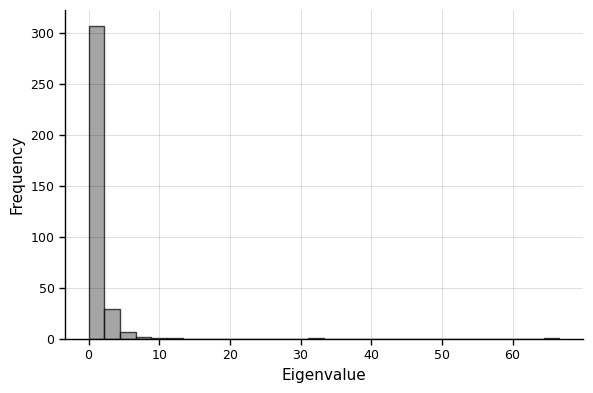

In [3]:
# Eigenvalue distribution of the first train epoch's correlation matrix
eigenvalues = np.linalg.eigvalsh(train["correlation_matrices"][0])
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(eigenvalues, bins=30, color=NEUTRAL_COLOURS["reference"], edgecolor="black", alpha=0.7)
ax.set_xlabel("Eigenvalue")
ax.set_ylabel("Frequency")
style_axis(ax, grid=True)
plt.tight_layout()
plt.show()

In [4]:
# Embed the graphs: Graph2Vec -> StandardScaler -> PCA(0.95), fit on train, transform both
X_train, g2v, scaler, pca, fit_diag = fit_embed(train_graphs)
X_test, test_diag = transform_embed(test_graphs, g2v, scaler, pca)
print(f"PCA-reduced embedding: train {X_train.shape[0]} x {X_train.shape[1]}, test {X_test.shape[0]} x {X_test.shape[1]}")
print(f"Retained PCA dimensions: {fit_diag['pca_dims']}")
print(f"Mean test OOV WL-feature rate: {np.mean(test_diag['oov_rate']):.3f}")

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


PCA-reduced embedding: train 465 x 104, test 164 x 104
Retained PCA dimensions: 104
Mean test OOV WL-feature rate: 0.572


C:\Users\Abbin\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\Abbin\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\Abbin\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\Abbin\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Wi

C:\Users\Abbin\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\Abbin\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\Abbin\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


C:\Users\Abbin\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


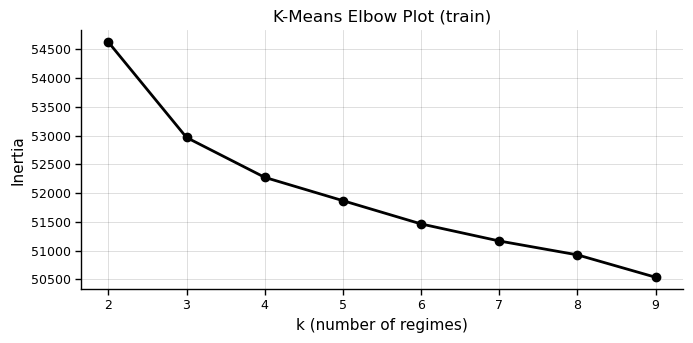

In [5]:
# K-means elbow: inertia across candidate k (train only)
k_range = range(2, 10)
inertias = [KMeans(n_clusters=k, random_state=42, n_init=20).fit(X_train).inertia_ for k in k_range]

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(list(k_range), inertias, marker="o", color=NEUTRAL_COLOURS["primary"], linewidth=2)
ax.set_xlabel("k (number of regimes)")
ax.set_ylabel("Inertia")
ax.set_title("K-Means Elbow Plot (train)")
style_axis(ax, grid=True)
plt.tight_layout()
plt.show()

In [6]:
# Fit K-means (k=3) on train, predict both, mu-rank the regimes from train only
km_train_labels, km_test_labels, km_model = cluster_kmeans(X_train, X_test, k)
order, rank_of_cluster, crisis_id, cluster_mean_mu = fit_regime_order(km_train_labels, train_mu, k)
print("Mean μ per regime (train):", {r: round(cluster_mean_mu[r], 3) for r in range(k)})
print("Crisis regime:", crisis_id)

km_order, km_rank_of_cluster, km_crisis_id = order, rank_of_cluster, crisis_id
km_train_ranked = apply_regime_order(km_train_labels, km_order)
km_test_ranked = apply_regime_order(km_test_labels, km_order)
assert np.array_equal(km_train_ranked, km_rank_of_cluster[np.asarray(km_train_labels)])
assert np.array_equal(km_test_ranked, km_rank_of_cluster[np.asarray(km_test_labels)])

Mean μ per regime (train): {0: np.float64(0.226), 1: np.float64(0.341), 2: np.float64(0.534)}
Crisis regime: 2


C:\Users\Abbin\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


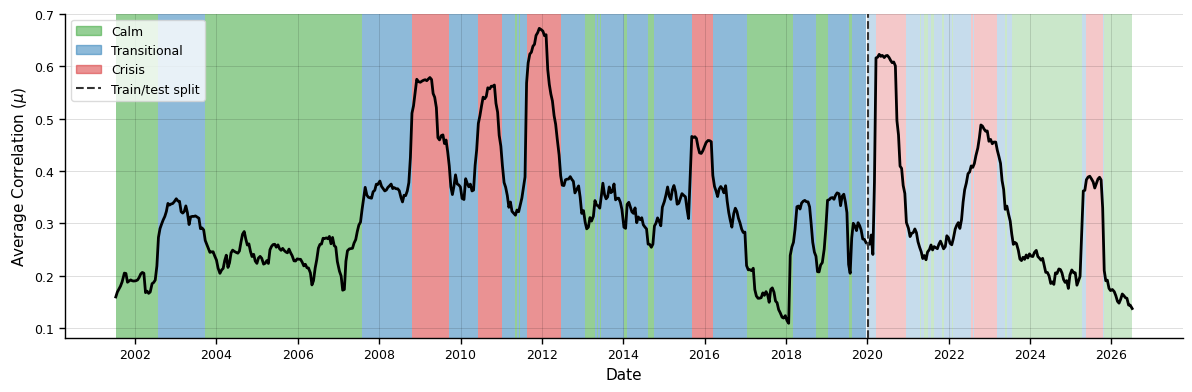

In [7]:
# Regime timeline shaded by mu-rank (K-means) -- train and test on one continuous axis
def plot_regime_timeline(train_dates, train_mu, train_labels, test_dates, test_mu, test_labels, rank_of_cluster):
    fig, ax = plt.subplots(figsize=(12, 4))

    def shade(dates, labels, alpha):
        for r in range(k):
            intervals = [(dates[i], dates[min(i + 1, len(dates) - 1)])
                         for i, lbl in enumerate(labels) if rank_of_cluster[lbl] == r]
            shade_periods(ax, intervals, REGIME_PALETTE[r], alpha=alpha)

    shade(train_dates, train_labels, alpha=0.5)
    shade(test_dates, test_labels, alpha=0.25)

    ax.plot(train_dates, train_mu, color="black", linewidth=2)
    ax.plot(test_dates, test_mu, color="black", linewidth=2)

    handles = [Patch(color=REGIME_PALETTE[r], alpha=0.5, label=REGIME_NAMES[r]) for r in range(k)]
    if len(test_dates) > 0:
        handles.append(mark_split(ax, test_dates[0]))

    ax.set_xlabel("Date")
    ax.set_ylabel(r"Average Correlation ($\mu$)")
    format_date_axis(ax)
    style_axis(ax, grid=True)
    ax.legend(handles=handles, loc="upper left", frameon=True, facecolor="white", edgecolor="lightgray")
    plt.tight_layout()
    plt.show()

plot_regime_timeline(train_dates, train_mu, km_train_labels, test_dates, test_mu, km_test_labels, rank_of_cluster)

In [8]:
# VIX validation F1 (K-means) -- train and test separately
res_train = validate_regime(km_train_labels, train_dates, vix, 30.0, crisis_id)
res_test = validate_regime(km_test_labels, test_dates, vix, 30.0, crisis_id)
print("train  point-in-time  precision {:.3f}  recall {:.3f}  F1 {:.3f}".format(*res_train["point"]))
print("test   point-in-time  precision {:.3f}  recall {:.3f}  F1 {:.3f}".format(*res_test["point"]))

train  point-in-time  precision 0.319  recall 0.479  F1 0.383
test   point-in-time  precision 0.205  recall 0.562  F1 0.300


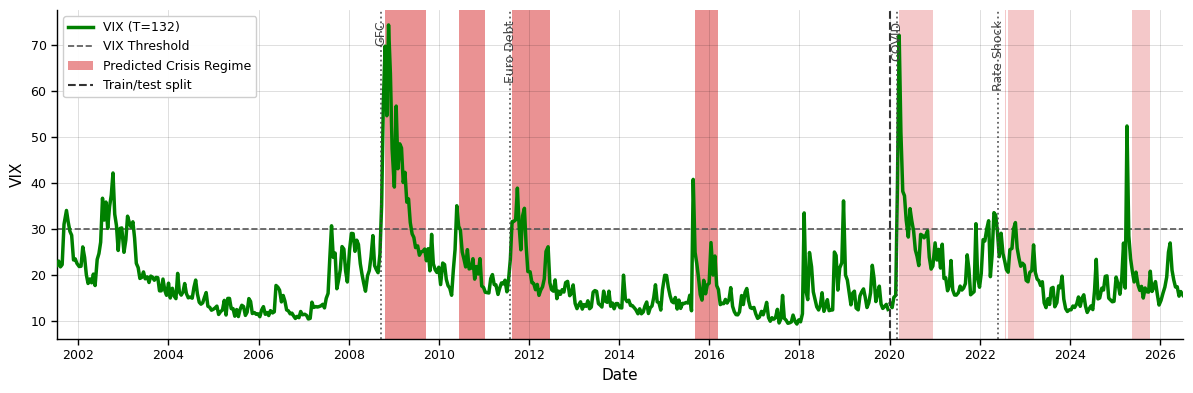

In [9]:
# VIX overlay with predicted-crisis shading, train and test on one continuous axis
def plot_vix_overlay(train_dates, res_train, test_dates, res_test):
    idx_train = pd.DatetimeIndex(pd.to_datetime(train_dates))
    idx_test = pd.DatetimeIndex(pd.to_datetime(test_dates))
    vix_color = EPOCH_LENGTH_COLOURS[EPOCH_LENGTH]
    fig, ax = plt.subplots(figsize=(12, 4))

    ax.plot(idx_train, res_train["series_eod"], color=vix_color, linewidth=2.5, zorder=3)
    ax.plot(idx_test, res_test["series_eod"], color=vix_color, linewidth=2.5, zorder=3)
    ax.axhline(30.0, color="#555555", linestyle="--", linewidth=1.2, zorder=2)

    def shade_crisis(idx, res, alpha):
        crisis_idx = np.where(res["pred"].astype(bool))[0]
        intervals = [(idx[i], idx[min(i + 1, len(idx) - 1)]) for i in crisis_idx]
        shade_periods(ax, intervals, REGIME_PALETTE[2], alpha=alpha)

    shade_crisis(idx_train, res_train, alpha=0.5)
    shade_crisis(idx_test, res_test, alpha=0.25)

    idx_all = idx_train.append(idx_test)
    annotate_events(ax, CRISIS_EVENTS, idx_all[0], idx_all[-1])

    handles = [Line2D([0], [0], color=vix_color, lw=2.5, label=f"VIX (T={EPOCH_LENGTH})"),
               Line2D([0], [0], color="#555555", lw=1.2, linestyle="--", label="VIX Threshold"),
               Patch(facecolor=REGIME_PALETTE[2], alpha=0.5, label="Predicted Crisis Regime")]
    if len(idx_test) > 0:
        handles.append(mark_split(ax, idx_test[0]))

    ax.set_xlabel("Date")
    ax.set_ylabel("VIX")
    ax.set_xlim(idx_all[0], idx_all[-1])
    format_date_axis(ax)
    style_axis(ax, grid=True)
    ax.legend(handles=handles, loc="upper left", frameon=True, framealpha=0.95, edgecolor="#CCCCCC")
    plt.tight_layout()
    plt.show()

plot_vix_overlay(train_dates, res_train, test_dates, res_test)

In [10]:
# HMM model selection: AIC by number of states (train only)
aic = {}
for n in range(2, 10):
    best_model, best_ll = None, -np.inf
    for seed in range(10):
        m = GaussianHMM(n_components=n, covariance_type="diag", n_iter=200, tol=1e-4, random_state=seed)
        try:
            m.fit(X_train)
            ll = m.score(X_train)
        except Exception:
            continue
        if ll > best_ll:
            best_model, best_ll = m, ll
    if best_model is not None:
        aic[n] = best_model.aic(X_train)
print("AIC by n_states (train):", {n: round(v, 1) for n, v in aic.items()})


C:\Users\Abbin\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\Abbin\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\Abbin\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


C:\Users\Abbin\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\Abbin\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\Abbin\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


C:\Users\Abbin\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\Abbin\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\Abbin\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\Abbin\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Wi

C:\Users\Abbin\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


C:\Users\Abbin\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\Abbin\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\Abbin\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


...

C:\Users\Abbin\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


C:\Users\Abbin\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


C:\Users\Abbin\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


C:\Users\Abbin\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


AIC by n_states (train): {2: 137883.0, 3: 137051.5, 4: 136941.5, 5: 137127.9, 6: 137069.4, 7: 137204.6, 8: 137288.2, 9: 137707.7}


In [11]:
# Fit best-of-20 HMM on train, predict both, mu-rank, transition matrix and dwell times (train)
hmm_train_labels, hmm_test_labels, hmm_model = cluster_hmm(X_train, X_test, k)
order, rank_of_cluster, crisis_id, cluster_mean_mu = fit_regime_order(hmm_train_labels, train_mu, k)
print("Mean μ per regime (train):", {r: round(cluster_mean_mu[r], 3) for r in range(k)})
print("Crisis regime:", crisis_id)

P, dwell = hmm_transitions(hmm_model, order)
print("Transition matrix P (μ-ranked, train):\n", np.round(P, 3))
for r, name in enumerate(REGIME_NAMES):
    print(f"{name:13s} self-transition {P[r, r]:.3f}   mean dwell {dwell[r]:.1f} windows")

C:\Users\Abbin\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


C:\Users\Abbin\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\Abbin\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\Abbin\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


C:\Users\Abbin\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\Abbin\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


C:\Users\Abbin\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\Abbin\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


C:\Users\Abbin\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\Abbin\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\Abbin\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


C:\Users\Abbin\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\Abbin\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


C:\Users\Abbin\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\Abbin\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\Abbin\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


C:\Users\Abbin\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\Abbin\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\Abbin\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


Mean μ per regime (train): {0: np.float64(0.229), 1: np.float64(0.532), 2: np.float64(0.342)}
Crisis regime: 1
Transition matrix P (μ-ranked, train):
 [[0.951 0.049 0.   ]
 [0.039 0.942 0.019]
 [0.    0.055 0.945]]
Calm          self-transition 0.951   mean dwell 20.5 windows
Transitional  self-transition 0.942   mean dwell 17.3 windows
Crisis        self-transition 0.945   mean dwell 18.2 windows


C:\Users\Abbin\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


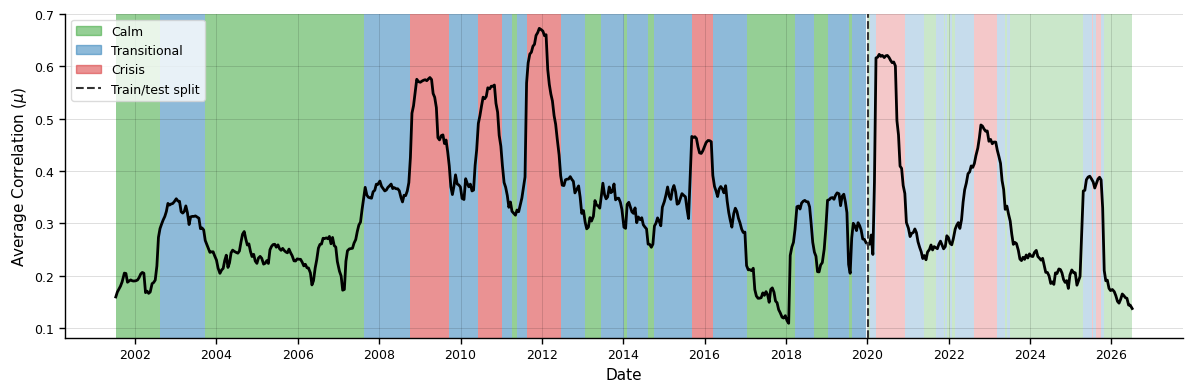

In [12]:
# Regime timeline shaded by mu-rank (HMM) -- train and test on one continuous axis
plot_regime_timeline(train_dates, train_mu, hmm_train_labels, test_dates, test_mu, hmm_test_labels, rank_of_cluster)

In [13]:
# VIX validation F1 (HMM) -- train and test separately
res_hmm_train = validate_regime(hmm_train_labels, train_dates, vix, 30.0, crisis_id)
res_hmm_test = validate_regime(hmm_test_labels, test_dates, vix, 30.0, crisis_id)
print("train  point-in-time  precision {:.3f}  recall {:.3f}  F1 {:.3f}".format(*res_hmm_train["point"]))
print("test   point-in-time  precision {:.3f}  recall {:.3f}  F1 {:.3f}".format(*res_hmm_test["point"]))

train  point-in-time  precision 0.329  recall 0.500  F1 0.397
test   point-in-time  precision 0.250  recall 0.562  F1 0.346


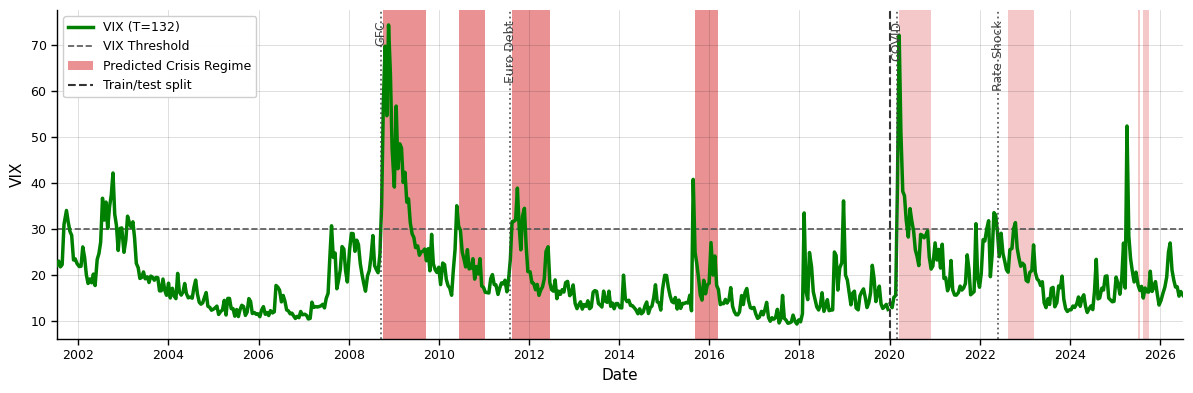

In [14]:
# VIX overlay with predicted-crisis shading (HMM), train and test on one continuous axis
plot_vix_overlay(train_dates, res_hmm_train, test_dates, res_hmm_test)

In [15]:
# Empirical train/test transition matrices for both clustering methods
emp_km_train, occ_km_train = empirical_transitions(km_train_labels, k, km_order)
emp_km_test, occ_km_test = empirical_transitions(km_test_labels, k, km_order)
print("K-means train transitions:\n", np.round(emp_km_train, 3), "\noccupancy:", occ_km_train)
print("K-means test transitions:\n", np.round(emp_km_test, 3), "\noccupancy:", occ_km_test)

emp_hmm_train, occ_hmm_train = empirical_transitions(hmm_train_labels, k, order)
emp_hmm_test, occ_hmm_test = empirical_transitions(hmm_test_labels, k, order)
print("\nHMM train transitions:\n", np.round(emp_hmm_train, 3), "\noccupancy:", occ_hmm_train)
print("HMM test transitions:\n", np.round(emp_hmm_test, 3), "\noccupancy:", occ_hmm_test)

K-means train transitions:
 [[0.932 0.068 0.   ]
 [0.051 0.93  0.019]
 [0.    0.056 0.944]] 
occupancy: [177 216  72]
K-means test transitions:
 [[0.897 0.103 0.   ]
 [0.157 0.765 0.078]
 [0.    0.091 0.909]] 
occupancy: [69 51 44]

HMM train transitions:
 [[0.951 0.049 0.   ]
 [0.039 0.942 0.019]
 [0.    0.055 0.945]] 
occupancy: [184 208  73]
HMM test transitions:
 [[0.908 0.092 0.   ]
 [0.137 0.784 0.078]
 [0.    0.111 0.889]] 
occupancy: [77 51 36]


In [16]:
# Load the raw arm's MST-threshold networks for Nikkei 225 (no VIX-equivalent series, so no F1/VIX-overlay cells below)
INDEX_CODE = "Nikkei225"
arm_data = load_arm(ARM, EPOCH_LENGTH, index_code=INDEX_CODE)
train, test = split_train_test(arm_data, cutoff=TRAIN_TEST_CUTOFF)
stock_names = arm_data["stock_names"]
train_graphs, test_graphs = train[GRAPH_KEY], test[GRAPH_KEY]
train_mu, test_mu = train["mu_values"], test["mu_values"]
train_dates, test_dates = train["epoch_dates"], test["epoch_dates"]
n_train_windows = len(train_dates)
print(f"train windows: {n_train_windows}, test windows: {len(test_dates)}")

train windows: 453, test windows: 159


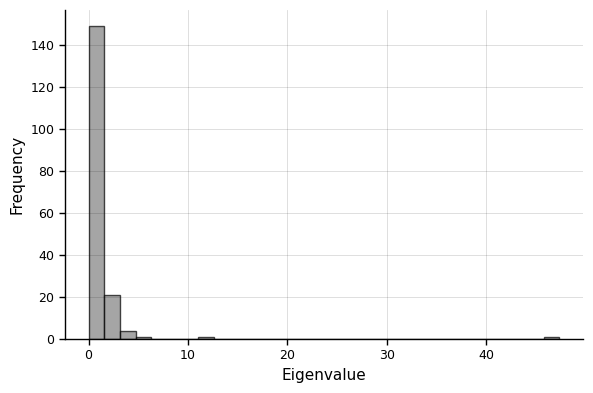

In [17]:
# Eigenvalue distribution of the first train epoch's correlation matrix (Nikkei 225)
eigenvalues = np.linalg.eigvalsh(train["correlation_matrices"][0])
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(eigenvalues, bins=30, color=NEUTRAL_COLOURS["reference"], edgecolor="black", alpha=0.7)
ax.set_xlabel("Eigenvalue")
ax.set_ylabel("Frequency")
style_axis(ax, grid=True)
plt.tight_layout()
plt.show()

In [18]:
# Embed the graphs: Graph2Vec -> StandardScaler -> PCA(0.95), fit on train, transform both (Nikkei 225)
X_train, g2v, scaler, pca, fit_diag = fit_embed(train_graphs)
X_test, test_diag = transform_embed(test_graphs, g2v, scaler, pca)
print(f"PCA-reduced embedding: train {X_train.shape[0]} x {X_train.shape[1]}, test {X_test.shape[0]} x {X_test.shape[1]}")
print(f"Retained PCA dimensions: {fit_diag['pca_dims']}")
print(f"Mean test OOV WL-feature rate: {np.mean(test_diag['oov_rate']):.3f}")

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


PCA-reduced embedding: train 453 x 86, test 159 x 86
Retained PCA dimensions: 86
Mean test OOV WL-feature rate: 0.542


In [19]:
# Fit K-means (k=3) on train, predict both, mu-rank the regimes from train only (Nikkei 225)
km_train_labels, km_test_labels, km_model = cluster_kmeans(X_train, X_test, k)
order, rank_of_cluster, crisis_id, cluster_mean_mu = fit_regime_order(km_train_labels, train_mu, k)
print("Mean μ per regime (train):", {r: round(cluster_mean_mu[r], 3) for r in range(k)})
print("Crisis regime:", crisis_id)

km_order, km_rank_of_cluster, km_crisis_id = order, rank_of_cluster, crisis_id
km_train_ranked = apply_regime_order(km_train_labels, km_order)
km_test_ranked = apply_regime_order(km_test_labels, km_order)
assert np.array_equal(km_train_ranked, km_rank_of_cluster[np.asarray(km_train_labels)])
assert np.array_equal(km_test_ranked, km_rank_of_cluster[np.asarray(km_test_labels)])

Mean μ per regime (train): {0: np.float64(0.408), 1: np.float64(0.537), 2: np.float64(0.306)}
Crisis regime: 1


C:\Users\Abbin\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


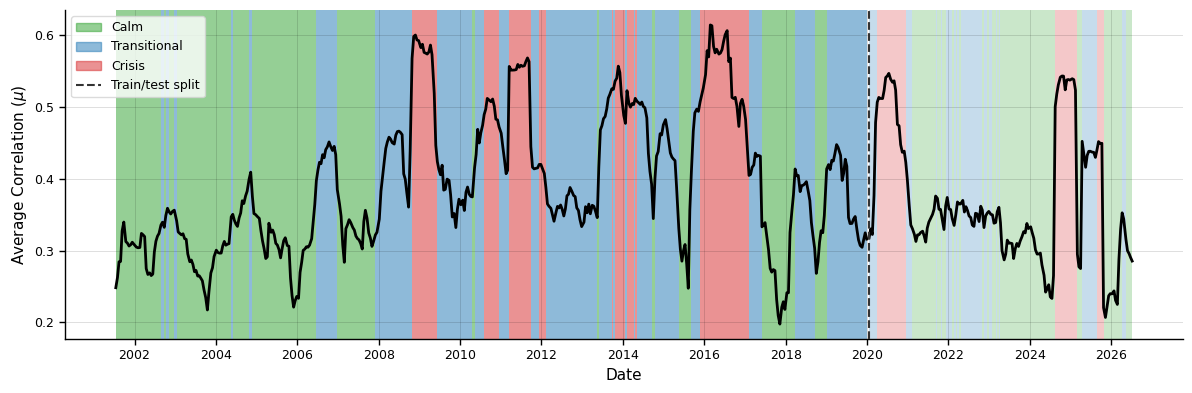

In [20]:
# Regime timeline shaded by mu-rank (K-means, Nikkei 225) -- train and test on one continuous axis
plot_regime_timeline(train_dates, train_mu, km_train_labels, test_dates, test_mu, km_test_labels, rank_of_cluster)

In [21]:
# Fit best-of-20 HMM on train, predict both, mu-rank, transition matrix and dwell times (train, Nikkei 225)
hmm_train_labels, hmm_test_labels, hmm_model = cluster_hmm(X_train, X_test, k)
order, rank_of_cluster, crisis_id, cluster_mean_mu = fit_regime_order(hmm_train_labels, train_mu, k)
print("Mean μ per regime (train):", {r: round(cluster_mean_mu[r], 3) for r in range(k)})
print("Crisis regime:", crisis_id)

P, dwell = hmm_transitions(hmm_model, order)
print("Transition matrix P (μ-ranked, train):\n", np.round(P, 3))
for r, name in enumerate(REGIME_NAMES):
    print(f"{name:13s} self-transition {P[r, r]:.3f}   mean dwell {dwell[r]:.1f} windows")

C:\Users\Abbin\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\Abbin\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\Abbin\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


C:\Users\Abbin\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\Abbin\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\Abbin\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


C:\Users\Abbin\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\Abbin\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\Abbin\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


C:\Users\Abbin\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\Abbin\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


C:\Users\Abbin\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\Abbin\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


C:\Users\Abbin\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\Abbin\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


C:\Users\Abbin\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\Abbin\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


C:\Users\Abbin\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\Abbin\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\Abbin\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


Mean μ per regime (train): {0: np.float64(0.543), 1: np.float64(0.405), 2: np.float64(0.306)}
Crisis regime: 0
Transition matrix P (μ-ranked, train):
 [[0.96  0.04  0.   ]
 [0.031 0.926 0.043]
 [0.    0.099 0.901]]
Calm          self-transition 0.960   mean dwell 25.0 windows
Transitional  self-transition 0.926   mean dwell 13.5 windows
Crisis        self-transition 0.901   mean dwell 10.1 windows


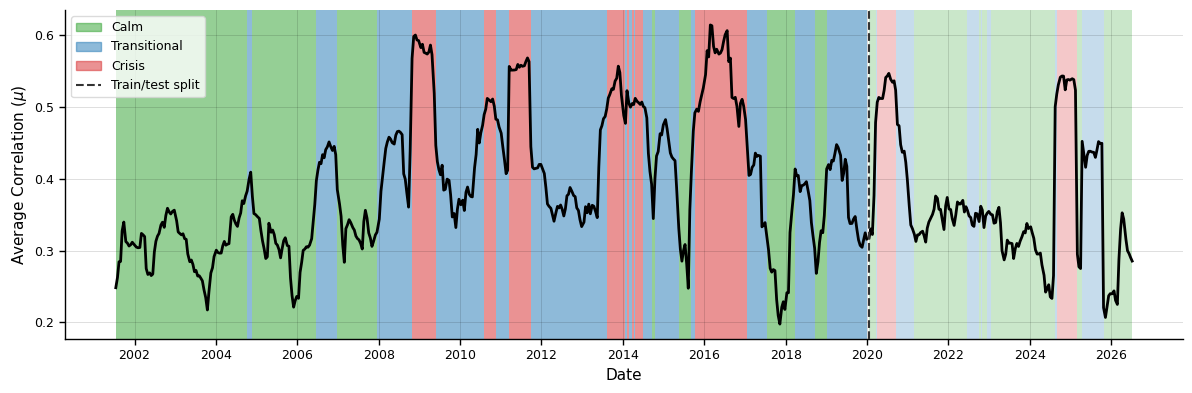

In [22]:
# Regime timeline shaded by mu-rank (HMM, Nikkei 225) -- train and test on one continuous axis
plot_regime_timeline(train_dates, train_mu, hmm_train_labels, test_dates, test_mu, hmm_test_labels, rank_of_cluster)

In [23]:
# Empirical train/test transition matrices for both clustering methods (Nikkei 225)
emp_km_train, occ_km_train = empirical_transitions(km_train_labels, k, km_order)
emp_km_test, occ_km_test = empirical_transitions(km_test_labels, k, km_order)
print("K-means train transitions:\n", np.round(emp_km_train, 3), "\noccupancy:", occ_km_train)
print("K-means test transitions:\n", np.round(emp_km_test, 3), "\noccupancy:", occ_km_test)

emp_hmm_train, occ_hmm_train = empirical_transitions(hmm_train_labels, k, order)
emp_hmm_test, occ_hmm_test = empirical_transitions(hmm_test_labels, k, order)
print("\nHMM train transitions:\n", np.round(emp_hmm_train, 3), "\noccupancy:", occ_hmm_train)
print("HMM test transitions:\n", np.round(emp_hmm_test, 3), "\noccupancy:", occ_hmm_test)

K-means train transitions:
 [[0.926 0.074 0.   ]
 [0.062 0.892 0.046]
 [0.    0.11  0.89 ]] 
occupancy: [175 196  82]
K-means test transitions:
 [[0.831 0.156 0.013]
 [0.255 0.702 0.043]
 [0.059 0.029 0.912]] 
occupancy: [78 47 34]

HMM train transitions:
 [[0.96  0.04  0.   ]
 [0.031 0.927 0.041]
 [0.    0.096 0.904]] 
occupancy: [176 194  83]
HMM test transitions:
 [[0.939 0.061 0.   ]
 [0.139 0.806 0.056]
 [0.043 0.043 0.913]] 
occupancy: [100  36  23]
